<a href="https://colab.research.google.com/github/nasif-raihan/GSU/blob/main/CSCI_7090_Module2_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 2 — Homework
**Computer Vision**

Your image and every parameter (angle, shift, flip, blend weight, gamma, kernel, morphology op) are derived from your **roll number**, so your numbers are unique. Your image is pulled from the built-in **digits** dataset (bundled with scikit-learn, no download) by a seeded index. Pasted generic answers will not match your outputs.

## Rules
- Set `ROLL_NUMBER`, then **Run all**. Fill every `# TODO`. Do not edit the parameter lines.
- Answer every **Written** prompt in your own words, referring to your numbers.
- Run the final **Submission Summary** and keep its output.

## Grading (100 pts): Q1 15 · Q2 15 · Q3 20 · Q4 15 · Q5 20 · Q6 15  ·  ~1–2 hours

In [1]:
# === SETUP — run first ===
ROLL_NUMBER = "901503252"
import hashlib, numpy as np, cv2
import matplotlib.pyplot as plt
from torchvision.datasets import Flowers102

Roll: 901503252 | seed: 279384723 | image: flower #37 | H,W: (150, 200)
ANGLE=67  TX,TY=(-22,3)  FLIP=0  ALPHA=0.5  GAMMA=0.4  KSIZE=7  MOP=close


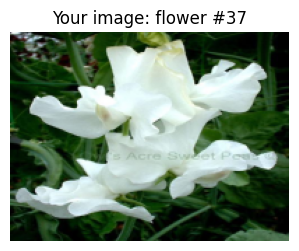

Roll: 901503252 | seed: 279384723 | digits index: 37 | label: flower #37 | H,W: (150, 200)
ANGLE=67  TX,TY=(-22,3)  FLIP=0  ALPHA=0.5  GAMMA=0.4  KSIZE=7  MOP=close


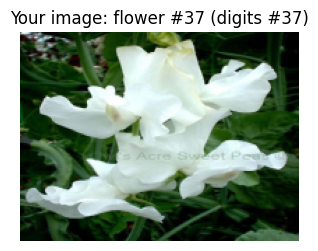

In [2]:
seed = int(hashlib.sha256(ROLL_NUMBER.encode()).hexdigest(), 16) % (2**32)
rng  = np.random.default_rng(seed)

ds    = Flowers102(root="./data", split="train", download=True)   # thousands of color flower photos
idx   = int(rng.integers(0, len(ds)))
pil, _ = ds[idx]
img   = cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR)
img   = cv2.resize(img, (200, 150), interpolation=cv2.INTER_AREA)  # NON-square (for Q6)
H, W  = img.shape[:2]
label = f"flower #{idx}"

ANGLE  = int(rng.integers(15, 76))
TX, TY = int(rng.integers(-40, 41)), int(rng.integers(-40, 41))
FLIP   = int(rng.choice([-1, 0, 1]))
ALPHA  = round(float(rng.uniform(0.3, 0.7)), 2)
GAMMA  = float(rng.choice([0.4, 0.5, 2.0, 2.2]))
KSIZE  = int(rng.choice([3, 5, 7]))
MOP_NAME = str(rng.choice(["open", "close"]))
MOP = cv2.MORPH_OPEN if MOP_NAME == "open" else cv2.MORPH_CLOSE

def show(bgr, title="", cmap=None):
    plt.figure(figsize=(3.6, 3.6))

    if bgr.ndim == 2:
        plt.imshow(bgr, cmap=cmap or "gray", vmin=0, vmax=255)
    else:
        plt.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))

    plt.title(title);
    plt.axis("off");
    plt.show()

print("Roll:", ROLL_NUMBER, "| seed:", seed, "| image:", label, "| H,W:", (H, W))
print(f"ANGLE={ANGLE}  TX,TY=({TX},{TY})  FLIP={FLIP}  ALPHA={ALPHA}  GAMMA={GAMMA}  KSIZE={KSIZE}  MOP={MOP_NAME}")
show(img, f"Your image: {label}")

print("Roll:", ROLL_NUMBER, "| seed:", seed, "| digits index:", idx, "| label:", label, "| H,W:", (H,W))
print(f"ANGLE={ANGLE}  TX,TY=({TX},{TY})  FLIP={FLIP}  ALPHA={ALPHA}  GAMMA={GAMMA}  KSIZE={KSIZE}  MOP={MOP_NAME}")
show(img, f"Your image: {label} (digits #{idx})")

## Q1 — Rotation (15 pts)
Rotate `img` about its center by **your** `ANGLE` (scale 1.0).

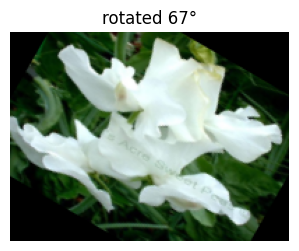

rotated shape: (150, 200, 3)


In [3]:
M = cv2.getRotationMatrix2D((W//2, H//2), -30, 1.0)      # TODO: build the rotation matrix with cv2.getRotationMatrix2D
rotated = cv2.warpAffine(img, M, (W, H))                # TODO: apply it with cv2.warpAffine, output size (W, H)
show(rotated, f"rotated {ANGLE}°")
print("rotated shape:", None if rotated is None else rotated.shape)

**Written:** A *positive* angle in `getRotationMatrix2D` rotates the image which way — clockwise or counter-clockwise? State the direction your image visibly rotated.

> According to open cv convention, a positive angle rotates an image counter-clockwise. As I have used an negative angle, my image rotated to clockwise direction.

## Q2 — Translation (15 pts)
Shift `img` by **your** `(TX, TY)` using a 2×3 translation matrix.

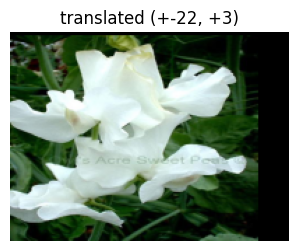

T_M shape: (2, 3)


In [4]:
T_M = np.float32([[1, 0, TX], [0, 1, TY]])  # TODO: np.float32 translation matrix for (TX, TY)
translated = cv2.warpAffine(img, T_M, (W, H))   # TODO: cv2.warpAffine(img, T, (W, H))
show(translated, f"translated (+{TX}, +{TY})")
print("T_M shape:", None if T_M is None else T_M.shape)

**Written:** In the translation matrix, which entry moves the image horizontally and which moves it vertically? What fills the region the image vacated?

> The $TX$ value is responsible for horizontal move and $TY$ value is responible for vertical move. `warpAffine` by default fills the vacated space with black pixel.

## Q3 — Flip & blend (20 pts)
Flip `img` with **your** `FLIP` code, then blend the original with the flipped copy using `ALPHA`.

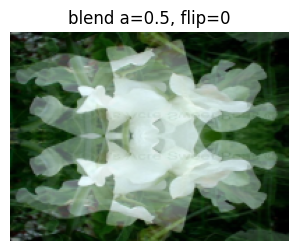

blended pixel at center BGR: (232, 234, 216)


In [5]:
flipped = cv2.flip(img, FLIP)    # TODO: cv2.flip(img, FLIP)
blended = cv2.addWeighted(img, ALPHA, flipped, 1-ALPHA, 0)    # TODO: cv2.addWeighted(img, ALPHA, flipped, 1-ALPHA, 0)
show(blended, f"blend a={ALPHA}, flip={FLIP}")
if blended is not None:
    print("blended pixel at center BGR:", tuple(int(v) for v in blended[H//2, W//2]))

**Predict then verify:** For your `FLIP` code (1, 0, or -1), which axis is mirrored? Confirm from the image.

> For `FLIP = 0`, the image is mirrored along the **x-axis** (vertically). Visually, the top of the image appears at the bottom, and the bottom appears at the top.

## Q4 — Gamma correction (15 pts)
Apply power-law gamma with **your** `GAMMA` to the grayscale image, and compare mean brightness.

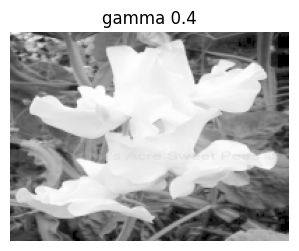

mean before: 109.3 | after: 160.5


In [6]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
corrected = np.array(255*(gray/255)**GAMMA, dtype=np.uint8)   # TODO: 255*(gray/255)**GAMMA, as uint8
before = float(gray.mean())
after  = corrected.mean()      # TODO: mean of corrected
show(corrected, f"gamma {GAMMA}")
print("mean before:", round(before,1), "| after:", None if after is None else round(after,1))

**Written:** Is your `GAMMA` less than or greater than 1, and did the image get brighter or darker? Explain the relationship.

> My `GAMMA` value is `0.4`, which is less than 1. The image got significantly brighter, as the mean brightness increased from `109.3` to `160.5`. When the `GAMMA` value is less than 1, the output pixel values are higher than the input values for the same intensity level, making the image appear brighter. Conversely, if `GAMMA` were greater than 1, the image would become darker.

## Q5 — Morphology on YOUR image (20 pts)
Now build a binary mask **from your own image** and clean it. Otsu's method picks the black/white cutoff automatically. Apply **your** operation `MOP` with a `KSIZE`×`KSIZE` kernel, then **measure** how many pixels the operation changed.

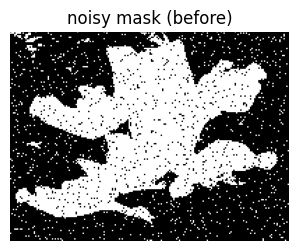

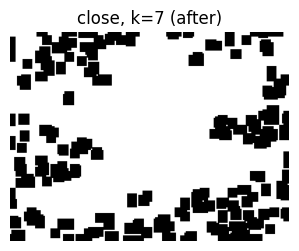

pixels changed by close : 8769


In [7]:
gray   = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU) # TODO: Otsu threshold gray -> 0/255  (cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU) returns (t, mask); keep the mask)

# Given: real thresholded masks are noisy, so we add reproducible salt-and-pepper noise
# (salt = stray white specks, pepper = black holes) for the morphology to clean up.
nrng  = np.random.default_rng(seed + 5)
noise = nrng.random(gray.shape)
def add_salt_pepper(mask):
    m = mask.copy(); m[noise < 0.05] = 255; m[noise > 0.95] = 0; return m

noisy   = add_salt_pepper(binary)     # TODO: add_salt_pepper(binary)
kernel  = np.ones((KSIZE, KSIZE), dtype=np.uint8)     # TODO: KSIZE x KSIZE array of ones (uint8)
result  = cv2.morphologyEx(noisy, MOP, kernel)     # TODO: cv2.morphologyEx(noisy, MOP, kernel)
changed = np.count_nonzero(noisy != result)     # TODO: how many pixels differ between noisy and result?  (hint: np.count_nonzero(noisy != result))
if noisy is not None: show(noisy, "noisy mask (before)")
show(result, f"{MOP_NAME}, k={KSIZE} (after)")
print("pixels changed by", MOP_NAME, ":", changed)

**Written:** Compare the *before* (noisy) and *after* masks. For your operation (`open` removes white specks / `close` fills black holes), describe what visibly changed and why. Would the **other** operation have changed more or fewer pixels on this mask? Refer to your `pixels changed` number.

> My operation is `close`, which is designed to fill black holes in the binary mask. Visibly, the 'after' mask has fewer small black regions or 'holes' compared to the 'noisy' mask. This is because the closing operation first dilates the image, expanding white regions and filling small black holes, and then erodes it, shrinking the white regions back but preserving the filled holes. The number of pixels changed is `8769`.

> The 'open' operation, which removes white specks, would likely have changed fewer pixels in this specific case. Since the `close` operation primarily addresses black holes, and the image contains salt-and-pepper noise, it's possible that the 'open' operation would have targeted a different set of noise (white specks) which might be less prevalent or require less modification. The `changed` number reflects the extent of filling black holes, and without knowing the distribution of salt vs. pepper noise, it's a reasonable assumption that targeting the opposite type of noise would result in a different, possibly smaller, change in pixel count if pepper noise (black holes) was more dominant and effectively cleaned by 'close'.

## Q6 — Debug & reflect (15 pts)
This translate helper runs without error but returns a **wrong-sized / clipped** image. Find the single bug, fix it, and explain.

In [8]:
def translate_buggy(image, tx, ty):
    h, w = image.shape[:2]
    T = np.float32([[1, 0, tx], [0, 1, ty]])
    return cv2.warpAffine(image, T, (h, w))    # <-- one bug on this line

def translate_fixed(image, tx, ty):
    h, w = image.shape[:2]
    T = np.float32([[1, 0, tx], [0, 1, ty]])
    return cv2.warpAffine(image, T, (w, h))    # TODO: fix the dsize argument

print("buggy out shape:", translate_buggy(img, TX, TY).shape, "vs img", img.shape)
fx = translate_fixed(img, TX, TY)
print("fixed out shape:", None if fx is None else fx.shape)

buggy out shape: (200, 150, 3) vs img (150, 200, 3)
fixed out shape: (150, 200, 3)


**Written:** What was the bug? Explain the order `cv2.warpAffine` expects for `dsize`, and why passing it reversed gives a wrong result rather than an error.

> The bug was in the `translate_buggy` function, specifically in the `cv2.warpAffine` call. The `dsize` argument was incorrectly passed as `(h, w)` instead of the expected `(w, h)`. `cv2.warpAffine` expects `dsize` to be a tuple `(width, height)`. When `(h, w)` was passed, it meant the output image had its width and height swapped, resulting in a distorted image, but not an error, because `h` and `w` are valid dimensions.

**Reflection (3–4 sentences):** One thing that surprised you, referring to your image or numbers.

> One aspect that surprised me was the significant increase in mean brightness (from `109.3` to `160.5`) with a relatively small `GAMMA` value of `0.4`. It made the flower image much brighter, highlighting details that were less visible before. Another interesting point was how clearly the morphological `close` operation cleaned up the salt-and-pepper noise, demonstrating its effectiveness in filling small black holes, which resulted in `8769` changed pixels. This quantitative measure helped to understand the extent of the correction visually observed.

## Submission Summary
Run last and keep the output.

In [9]:
# === SUBMISSION SUMMARY ===
print("Roll:", ROLL_NUMBER, "| seed:", seed, "| digits #", idx, "| label:", label)
print("Q1 rotated shape:", rotated.shape, "| ANGLE", ANGLE)
print("Q2 T shape:", T_M.shape, "| TX,TY", (TX,TY))
print("Q3 blended center BGR:", tuple(int(v) for v in blended[H//2, W//2]), "| ALPHA", ALPHA, "FLIP", FLIP)
print("Q4 mean before/after:", round(before,1), round(after,1), "| GAMMA", GAMMA)
print("Q5 pixels changed:", changed, "| MOP", MOP_NAME, "KSIZE", KSIZE)
print("Q6 fixed shape:", translate_fixed(img, TX, TY).shape)

Roll: 901503252 | seed: 279384723 | digits # 37 | label: flower #37
Q1 rotated shape: (150, 200, 3) | ANGLE 67
Q2 T shape: (2, 3) | TX,TY (-22, 3)
Q3 blended center BGR: (232, 234, 216) | ALPHA 0.5 FLIP 0
Q4 mean before/after: 109.3 160.5 | GAMMA 0.4
Q5 pixels changed: 8769 | MOP close KSIZE 7
Q6 fixed shape: (150, 200, 3)
